# Feature Sifting — step-size protected feature search

This notebook studies the **feature sifting** task (`phd/jax_core/tasks/feature_sifting.py`): an online
single-sample regression problem where the learner observes `n_learner_features` noisy candidate features,
each a noisy view of one of `n_target_features` true features. The target is a fixed weighted sum (weights
±1) of the true features. The learner predicts the target with a **linear model** and, each step, may mark
candidate slots for replacement (`prune_mask`); pruned slots are regenerated by the task with a fresh random
target index and noise coefficient. The learner must continually *sift* useful (low-noise) candidates from
useless ones.

Every method here uses the **Autostep** (IDBD) optimizer as its base learner, and differs only in *how it
decides to throw a feature away* (its generate-and-test rule). Each method is a self-contained `eqx.Module`
— read the class and you see the entire method.

### Methods compared
1. **Autostep** — Autostep online linear regression on a **fixed** candidate set (never prunes). The baseline
   with no feature search.
2. **Autostep + Generate & Test (Autostep + G&T)** — the simplest utility-based pruner: every `prune_period`
   steps, drop the single lowest-magnitude weight (utility = `|weight|`) and regenerate that slot. Like CBP,
   but the utility is just the weight magnitude and pruning is on a fixed clock.
3. **Autostep + G&T + step-size protection (median threshold)** — event-driven pruning. A feature becomes a
   prune candidate the step its Autostep gradient trace `h` flips sign; it is pruned only if its weight
   magnitude is in the **bottom half** of the current weights (`|w_i| < median |w|`).
4. **Autostep + G&T + step-size protection (sign-flip)** — a feature is pruned when its weight crosses zero
   while `|h_i|` sits inside its one-sigma jitter band `s_i / sqrt(2)`, with
   `s_i = sqrt(alpha_i · E[delta^2] / 2)` built online from the learned step-size and a running estimate of
   the residual power. No L1, no arming.
5. **Autostep + L1 + G&T (zero-crossing)** — the L1 subgradient `lambda · sign(w)` joins the loss gradient
   (`lambda = 0.001`), so L1 pulls every weight toward zero and only a real gradient holds one away from it.
   A feature is pruned the step its **weight changes sign** — no threshold, no clock.
6. **Autostep + L1 + G&T (armed jitter band)** — method 5 plus a second kill built on the jitter band of
   method 4: once `|h_i|` has left its band at least once (**arming**), a feature is also pruned when
   `|h_i|` crosses back **into** the band while its utility is in the bottom half of the weights.

### Jitter bands
Methods 4 and 6 test `h` against the noise-floor jitter bands derived and empirically validated in
`lasso_step_size_protection_algo.ipynb`: for a dead feature,
`|w_i| <= s_i - lambda / E[x_i^2]` and `|h_i| <= s_i / sqrt(2)` with `s_i = sqrt(alpha_i · E[delta^2] / 2)`,
each a one-sigma band. Those bands are derived for the **LMS gradient convention** `delta · x`, so
`linear_loss_and_grads` below uses it (the factor 2 of the exact squared-error gradient is folded into the
step-size, which every method sweeps anyway).

### How sweeping / caching works
Each method is run as an **mlflow-sweeper** grid sweep (programmatic `run_sweep`). Every configuration runs
`N` seeds batched in a single `jax.lax.scan` (jitted end-to-end) and logs the binned learning curve
(`loss`, `loss_std` = mean / std across seeds) plus a scalar `final_loss`. Because the sweeps and metrics
live in local MLflow/Optuna stores, **the experiments only run on the first execution** — re-running the
notebook finds the studies complete and just reloads the cached data.

In [1]:
import os
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import jax
import jax.numpy as jnp
import optax
import equinox as eqx
import mlflow
from omegaconf import OmegaConf

from mlflow_sweeper import SweepConfig, run_sweep, delete_sweep

from phd.jax_core.tasks.feature_sifting import FeatureSiftingTask
from phd.jax_core.optimizers.idbd import optax_idbd, IDBDState
from phd.jax_core.utils import tree_replace

from phd.research_utils.scripts.mlflow_download import download_experiment
from phd.research_utils.analysis.analysis_utils import (
    load_experiment_data, get_best_ablation_values, get_color_palette,
)

sns.set_theme('notebook', 'white')
%matplotlib inline

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Storage is kept in local files **relative to this notebook**, so the sweep state and logged metrics persist
across runs. Adjust `NUM_STEPS` / seed counts / grids below to trade off runtime vs. resolution.

In [2]:
EXPERIMENT = 'feature_sifting_protection'
NOTEBOOK_DIR = os.path.abspath('.')
DATA_DIR = os.path.join(NOTEBOOK_DIR, 'data')
SWEEP_OUTPUT_DIR = os.path.join(NOTEBOOK_DIR, 'sweep_output')
MLFLOW_URI = f"sqlite:///{os.path.join(NOTEBOOK_DIR, 'output', 'mlruns.db')}"
OPTUNA_URI = f"sqlite:///{os.path.join(NOTEBOOK_DIR, 'output', 'optuna.db')}"

os.environ['MLFLOW_TRACKING_URI'] = MLFLOW_URI
mlflow.set_tracking_uri(MLFLOW_URI)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(SWEEP_OUTPUT_DIR, exist_ok=True)

# Task / training configuration.
N_TARGET_FEATURES = 10
N_LEARNER_FEATURES = 20
TARGET_NOISE_STD = 0.0
NUM_STEPS = 50_000
BASE_SEED = 0
N_SWEEP_SEEDS = 5       # seeds batched per sweep configuration
N_CURVE_SEEDS = 30      # seeds for the final best-config learning curves
N_LOG_POINTS = 250      # binned points logged per run (learning-curve resolution)
FINAL_FRACTION = 0.05   # last 5% of steps define the summary 'final loss'

# Loss of the trivial predictor (always predicts 0): E[y^2]. Each target weight is +-1
# and target features are uniform[-1, 1] (variance 1/3). Anything that learns beats this;
# anything that diverges exceeds it. Used as the convergence threshold for sensitivity plots.
BASELINE_LOSS = N_TARGET_FEATURES / 3.0 + TARGET_NOISE_STD ** 2

# Portion of the sweep config shared by every method.
BASE_SWEEP_CONFIG = {
    'experiment': EXPERIMENT,
    'optuna_storage': OPTUNA_URI,
    'mlflow_storage': MLFLOW_URI,
    'output_dir': SWEEP_OUTPUT_DIR,
    'algorithm': 'grid',
    'spec': {'direction': 'minimize', 'metric': 'final_loss'},
}
print('MLflow store :', MLFLOW_URI)
print('Baseline loss:', round(BASELINE_LOSS, 4))

MLflow store : sqlite:////home/edan/local_projects/phd_research/phd/sandbox/feature_sifting/exploration/output/mlruns.db
Baseline loss: 3.3333


## Core: the learner and shared primitives

A single linear layer `w` of shape `(1, n_learner_features)` predicts `y_hat = w · x` — the natural learner
for this task, and Autostep-compatible (2D weight, no bias). The loss is the squared prediction error on the
freshly observed sample.

**Method interface.** Each method (one per cell below) is an `eqx.Module` that bundles its own `init` and
`step`:

* `Method.init(hparams, key) -> Method` builds the Autostep optimizer, weights, and any algorithm state.
  Static hyperparameters (the optimizer, the prune period / constants) are `eqx.field(static=True)`; the
  dynamic state (weights, optimizer state, per-feature traces, …) are ordinary array fields.
* `method.step(x, y) -> (method, loss)` predicts, learns, and returns the updated module. It also carries a
  `prune_mask` field telling the task which candidate slots to regenerate next (all-`False` for methods that
  never recycle).

Only two things are shared across methods, and both are deliberately tiny so each method reads end-to-end on
its own: `linear_loss_and_grads` (the squared-error loss + its **LMS-convention** gradient `delta · x`) and
`reset_idbd_state` (put a pruned slot's Autostep state back to initial, exactly as continual-backprop does
when it recycles a feature).

In [3]:
def linear_loss_and_grads(w, x, y):
    """Squared-error loss of the linear prediction, and the LMS gradient `delta * x`.

    This is the exact gradient up to the constant factor 2, which is folded into the step-size (every
    method sweeps it). The convention matters because the jitter bands the protection rules use --
    `s_i = sqrt(alpha_i * E[delta^2] / 2)` for `w` and `s_i / sqrt(2)` for `h` -- are derived and
    empirically validated for `delta * x` in `lasso_step_size_protection_algo.ipynb`; a factor c in the
    gradient rescales both bands."""
    y_hat = jnp.sum(w * x[None, :])
    error = y_hat - y
    return error ** 2, error * x[None, :]


def reset_idbd_state(opt_state, prune_mask):
    """Reset per-feature Autostep (IDBD) state for pruned / regenerated slots: step-size back
    to its initial value, and the gradient trace `h` and normaliser `v` to zero. `prune_mask` is
    a boolean array of shape (n_features,)."""
    m = prune_mask[None, :]   # broadcast over the single output row -> (1, n_features)
    return IDBDState(
        init_beta=opt_state.init_beta,
        beta=jnp.where(m, opt_state.init_beta, opt_state.beta),  # step-size -> initial
        h=jnp.where(m, 0.0, opt_state.h),
        v=jnp.where(m, 0.0, opt_state.v),
    )

def noise_floor(task):
    """Loss floor of the task's *current* feature set: for each of the ``n_target_features`` unique
    target features, the lowest noise coefficient among the candidate slots pointing at it (``1.0``
    for an uncovered target), summed. Lower-noise candidates covering more targets -> a lower floor,
    so this tracks the quality of the feature set a method has assembled."""
    target_idxs = jnp.arange(task.n_target_features)
    def min_noise_for_target(idx):
        points_here = task.learner_feature_idxs == idx
        return jnp.where(points_here.any(),
                         jnp.min(jnp.where(points_here, task.noise_coefficients, 1.0)),
                         1.0)
    return jnp.sum(jax.vmap(min_noise_for_target)(target_idxs))

## Sweep infrastructure

`MethodSpec` records a method's class, default hyperparameters, and label; each method registers itself in
`METHODS` from its own cell. `run_all_seeds` runs every seed of a config batched in a single jitted
`jax.lax.scan` — the loop only calls the module's `init` / `step` and routes `prune_mask` to the task.
`run_method_sweep` turns a grid into a programmatic mlflow-sweeper sweep (the objective fills in `defaults`
for any hyperparameter the grid does not sweep, and logs via `log_run`); `load_sweep_data` returns the
standard `config_dfs` / `run_dfs` dicts, downloading only when new runs have appeared.

In [4]:
import sys
if NOTEBOOK_DIR not in sys.path:           # make the sibling experiment_logging.py importable
    sys.path.insert(0, NOTEBOOK_DIR)
from experiment_logging import log_run, summarize_runs, plot_sensitivity, plot_learning_curve


@dataclass
class MethodSpec:
    name: str          # mlflow sweep_name
    label: str         # human-readable label for plots
    cls: type          # eqx.Module with .init(hparams, key) and .step(x, y) -> (module, loss)
    defaults: dict     # default hyperparameters; the grid overrides the subset it sweeps


METHODS = {}           # each method's cell below registers itself here


def swept_vars(grid):
    """The grid keys that actually vary (more than one value) — the swept hyperparameters."""
    return [k for k, vals in grid.items() if len(vals) > 1]


def run_all_seeds(method_cls, hparams, n_seeds):
    """Run `n_seeds` seeds (batched + jitted) of `method_cls` at `hparams`; losses (n_seeds, NUM_STEPS)."""
    def run_one_seed(seed_key):
        task_key, init_key = jax.random.split(seed_key)
        task = FeatureSiftingTask(N_TARGET_FEATURES, N_LEARNER_FEATURES, TARGET_NOISE_STD, key=task_key)
        state = method_cls.init(hparams, init_key)

        def scan_step(carry, _):
            task, state = carry
            task, (x, y) = task.step(state.prune_mask)     # task regenerates the recycled slots
            state, loss = state.step(x, jnp.squeeze(y))
            return (task, state), loss

        _, losses = jax.lax.scan(scan_step, (task, state), length=NUM_STEPS)
        return losses

    seed_keys = jax.random.split(jax.random.PRNGKey(BASE_SEED), n_seeds)
    return jax.jit(jax.vmap(run_one_seed))(seed_keys)


def make_objective(spec):
    def objective(**params):
        n_seeds = int(params.pop('n_seeds'))
        hparams = {**spec.defaults, **{k: float(v) for k, v in params.items()}}
        return log_run(run_all_seeds(spec.cls, hparams, n_seeds), N_LOG_POINTS, FINAL_FRACTION)
    return objective


def run_method_sweep(spec, grid, n_seeds, sweep_name=None, n_jobs=1, overwrite=False):
    sweep_name = sweep_name or spec.name
    params = dict(grid)
    params['n_seeds'] = int(n_seeds)
    cfg = {**BASE_SWEEP_CONFIG, 'sweep_name': sweep_name, 'parameters': params}
    config = SweepConfig.from_dict_config(OmegaConf.create(cfg))
    # End any lingering active run so re-running an already-complete sweep doesn't raise
    # "Run ... is already active".
    if mlflow.active_run() is not None:
        mlflow.end_run()

    if overwrite:
        delete_sweep(config)

    # allow_param_change updates the sweep in place when the config differs from the stored
    # one — e.g. after moving the MLflow/Optuna stores, or after editing a grid. Matching
    # trials are migrated (no recompute); only new/removed grid points actually run.
    run_sweep(config, make_objective(spec), n_jobs=n_jobs, log_params=True, no_plots=True,
              allow_param_change=True, executor='thread')


PARAMS_CSV = os.path.join(DATA_DIR, f'{EXPERIMENT}_params.csv')
METRICS_CSV = os.path.join(DATA_DIR, f'{EXPERIMENT}_metrics.csv')
RUN_COUNT_MARKER = os.path.join(DATA_DIR, f'.{EXPERIMENT}_run_count')


def _n_finished_runs():
    """Number of finished MLflow runs in the experiment (cheap; no metric history)."""
    client = mlflow.tracking.MlflowClient()
    exp = client.get_experiment_by_name(EXPERIMENT)
    if exp is None:
        return 0
    return len(client.search_runs([exp.experiment_id],
                                  filter_string="attributes.status = 'FINISHED'",
                                  max_results=50000))


def load_sweep_data(force_download=False):
    """Load the experiment's CSVs, downloading from MLflow only when needed.

    The download is skipped (cached CSVs are reloaded) whenever no new finished runs
    have appeared since the last download, so re-running analysis cells does not
    re-download. Pass ``force_download=True`` to force a fresh download.
    """
    n_runs = _n_finished_runs()
    have_csv = os.path.exists(PARAMS_CSV) and os.path.exists(METRICS_CSV)
    cached_n = int(open(RUN_COUNT_MARKER).read()) if os.path.exists(RUN_COUNT_MARKER) else -1
    if force_download or not have_csv or n_runs != cached_n:
        download_experiment(EXPERIMENT, output_dir=DATA_DIR, tracking_uri=MLFLOW_URI)
        with open(RUN_COUNT_MARKER, 'w') as f:
            f.write(str(n_runs))
    else:
        print(f'Reusing cached CSVs ({n_runs} runs, no new data to download).')
    return load_experiment_data(PARAMS_CSV, METRICS_CSV)


def best_hparams(cfgs, runs, spec, grid):
    """Best (min final-avg loss) hyperparameters for a method's grid sweep."""
    sv = swept_vars(grid)
    _, _, best = get_best_ablation_values(
        {spec.name: cfgs[spec.name]}, {spec.name: runs[spec.name]},
        sweep_ablation_vars={spec.name: sv},
        metric_col='loss', metric_direction='min', metric_type='final_avg',
        nan_policy='propagate', print_best_values=False,
    )
    return {key: float(val) for key, val in best[spec.name].items()}

## 1. Autostep

Autostep online linear regression on the **fixed** initial candidate set — no feature search. Sweeps the
initial step-size and the meta step-size.

In [5]:
class Autostep(eqx.Module):
    """Autostep (IDBD) online linear regression on a fixed candidate set; never recycles features."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls, hparams, key):
        n = N_LEARNER_FEATURES
        optimizer = optax_idbd(init_lr=hparams['learning_rate'],
                               meta_lr=hparams['meta_learning_rate'], autostep=True)
        w = jnp.zeros((1, n))
        return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
                   prune_mask=jnp.zeros(n, dtype=bool))

    def step(self, x, y):
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        # Autostep/IDBD consumes both the loss gradient and the prediction gradient (= x).
        updates, opt_state = self.optimizer.update((loss_grads, x[None, :]), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)
        return tree_replace(self, w=w, opt_state=opt_state), loss   # prune_mask stays all-False


AUTOSTEP_DEFAULTS = {'learning_rate': 2.0 ** -2, 'meta_learning_rate': 2.0 ** -4}
METHODS['autostep'] = MethodSpec('autostep', 'Autostep', Autostep, AUTOSTEP_DEFAULTS)

[I 2026-08-07 11:57:37,826] A new study created in RDB with name: feature_sifting_protection/autostep
INFO:mlflow_sweeper.runner:Creating new parent MLflow run: autostep.
INFO:mlflow_sweeper.runner:Sweep run #0.
INFO:mlflow_sweeper.runner:Created trial MLflow run: b1da0d0f108849b0a4eb74587eb51ca1.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(learning_rate=0.25, meta_learning_rate=0.015625, n_seeds=5)`
INFO:2026-08-07 11:57:38,518:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
[I 2026-08-07 11:57:41,534] Trial 0 finished with value: 1.644760599358841 and parameters: {'learning_rate': 0.25, 'meta_learning_rate': 0.015625}. Best is trial 0 with value: 1.64476059935

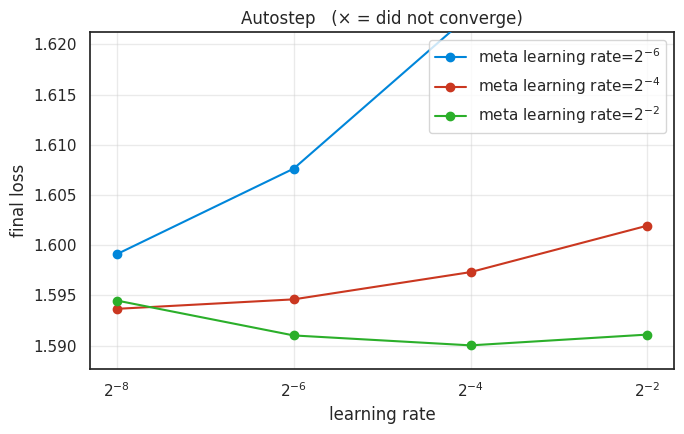

In [6]:
AUTOSTEP_GRID = {
    'learning_rate': [2.0 ** e for e in range(-8, -1, 2)],       # 2^-8 .. 2^-2  (initial step-size)
    'meta_learning_rate': [2.0 ** e for e in range(-6, -1, 2)],  # 2^-6 .. 2^-2
}
run_method_sweep(METHODS['autostep'], AUTOSTEP_GRID, N_SWEEP_SEEDS)
cfgs, runs = load_sweep_data()
autostep_summary = summarize_runs(cfgs, runs, 'autostep', swept_vars(AUTOSTEP_GRID), FINAL_FRACTION, BASELINE_LOSS)
plot_sensitivity(autostep_summary, swept_vars(AUTOSTEP_GRID), 'Autostep')
plt.show()

### Autostep — best configuration learning curve (30 seeds)

[I 2026-08-07 11:58:11,669] A new study created in RDB with name: feature_sifting_protection/autostep_best


INFO:mlflow_sweeper.runner:Creating new parent MLflow run: autostep_best.
INFO:mlflow_sweeper.runner:Sweep run #0.
INFO:mlflow_sweeper.runner:Created trial MLflow run: 10f6b84213f7454c88e62073728aaef2.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(learning_rate=0.0625, meta_learning_rate=0.25, n_seeds=30)`


Autostep best: {'learning_rate': 0.0625, 'meta_learning_rate': 0.25}


[I 2026-08-07 11:58:14,603] Trial 0 finished with value: 1.2694375352908167 and parameters: {}. Best is trial 0 with value: 1.2694375352908167.
INFO:mlflow_sweeper.runner:Sweep autostep_best completed.
INFO:phd.research_utils.scripts.mlflow_download:Tracking URI: sqlite:////home/edan/local_projects/phd_research/phd/sandbox/feature_sifting/exploration/output/mlruns.db
INFO:phd.research_utils.scripts.mlflow_download:Found experiment 'feature_sifting_protection' (id=2)
INFO:phd.research_utils.scripts.mlflow_download:Found 15 runs
INFO:phd.research_utils.scripts.mlflow_download:Discovered 4 metric names from 10 sample runs
INFO:phd.research_utils.scripts.mlflow_download:Metrics to download: ['final_loss', 'final_loss_std', 'loss', 'loss_std']
Downloading: 100%|██████████| 15/15 [00:01<00:00, 10.39it/s]
INFO:phd.research_utils.scripts.mlflow_download:Saved 15 param rows to /home/edan/local_projects/phd_research/phd/sandbox/feature_sifting/exploration/data/feature_sifting_protection_params.c

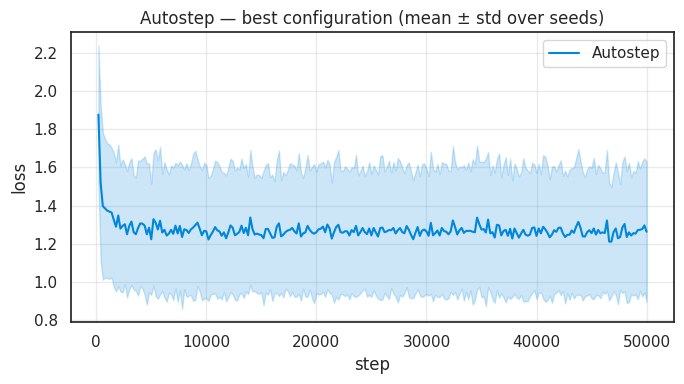

In [7]:
autostep_best = best_hparams(cfgs, runs, METHODS['autostep'], AUTOSTEP_GRID)
print('Autostep best:', autostep_best)
run_method_sweep(METHODS['autostep'], autostep_best, N_CURVE_SEEDS, sweep_name='autostep_best')
cfgs, runs = load_sweep_data()

plt.figure(figsize=(7, 4))
plot_learning_curve(runs, 'autostep_best', label='Autostep', color=get_color_palette(n=4)[0])
plt.title('Autostep — best configuration (mean ± std over seeds)')
plt.legend(); plt.tight_layout(); plt.show()

## 2. Autostep + Generate & Test

The simplest generate-and-test rule: every `prune_period` steps, drop the single lowest-magnitude weight
(utility = `|weight|`) and regenerate that slot. Like CBP, but the utility is just the weight magnitude and
pruning fires on a fixed clock rather than a replacement-rate accumulator. Sweeps step-size, meta step-size,
and the prune period.

In [8]:
class AutostepGT(eqx.Module):
    """Autostep + Generate & Test. Every `prune_period` steps, prune the single lowest-magnitude
    weight (utility = |weight|); the pruned slot is regenerated by the task and its Autostep state
    is reset to initial."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    prune_period: int = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    step_idx: jax.Array
    prune_mask: jax.Array

    @classmethod
    def init(cls, hparams, key):
        n = N_LEARNER_FEATURES
        optimizer = optax_idbd(init_lr=hparams['learning_rate'],
                               meta_lr=hparams['meta_learning_rate'], autostep=True)
        w = jnp.zeros((1, n))
        return cls(optimizer=optimizer, prune_period=int(hparams['prune_period']),
                   w=w, opt_state=optimizer.init(w), step_idx=jnp.array(0),
                   prune_mask=jnp.zeros(n, dtype=bool))

    def step(self, x, y):
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        updates, opt_state = self.optimizer.update((loss_grads, x[None, :]), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)

        # Every `prune_period` steps, prune the single lowest-magnitude weight.
        step_idx = self.step_idx + 1
        should_prune = (step_idx % self.prune_period) == 0
        utility = jnp.abs(w[0])
        prune_mask = should_prune & (jnp.arange(w.shape[1]) == jnp.argmin(utility))
        w = jnp.where(prune_mask[None, :], 0.0, w)
        opt_state = reset_idbd_state(opt_state, prune_mask)

        return tree_replace(self, w=w, opt_state=opt_state, step_idx=step_idx,
                            prune_mask=prune_mask), loss


AUTOSTEP_GT_DEFAULTS = {'learning_rate': 2.0 ** -2, 'meta_learning_rate': 2.0 ** -4,
                        'prune_period': 2 ** 10}
METHODS['autostep_gt'] = MethodSpec('autostep_gt', 'Autostep + G&T', AutostepGT, AUTOSTEP_GT_DEFAULTS)

[I 2026-08-07 11:58:16,422] A new study created in RDB with name: feature_sifting_protection/autostep_gt


INFO:mlflow_sweeper.runner:Creating new parent MLflow run: autostep_gt.
INFO:mlflow_sweeper.runner:Sweep run #0.
INFO:mlflow_sweeper.runner:Created trial MLflow run: aca84efa7c9d4745babc529b24c38a81.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(learning_rate=0.00390625, meta_learning_rate=0.0625, prune_period=2048, n_seeds=5)`
[I 2026-08-07 11:58:20,116] Trial 0 finished with value: 0.3764533335803241 and parameters: {'learning_rate': 0.00390625, 'meta_learning_rate': 0.0625, 'prune_period': 2048}. Best is trial 0 with value: 0.3764533335803241.
INFO:mlflow_sweeper.runner:Sweep run #1.
INFO:mlflow_sweeper.runner:Created trial MLflow run: 81991586a8ee426c839cb0eada58273d.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(learning_rate=0.25, meta_learning_rate=0.015625, prune_period=512, n_seeds=5)`
[I 2026-08-07 11:58:23,747] Trial 1 finished with value: 0.06420384082841075 and parameters: {'learning_ra

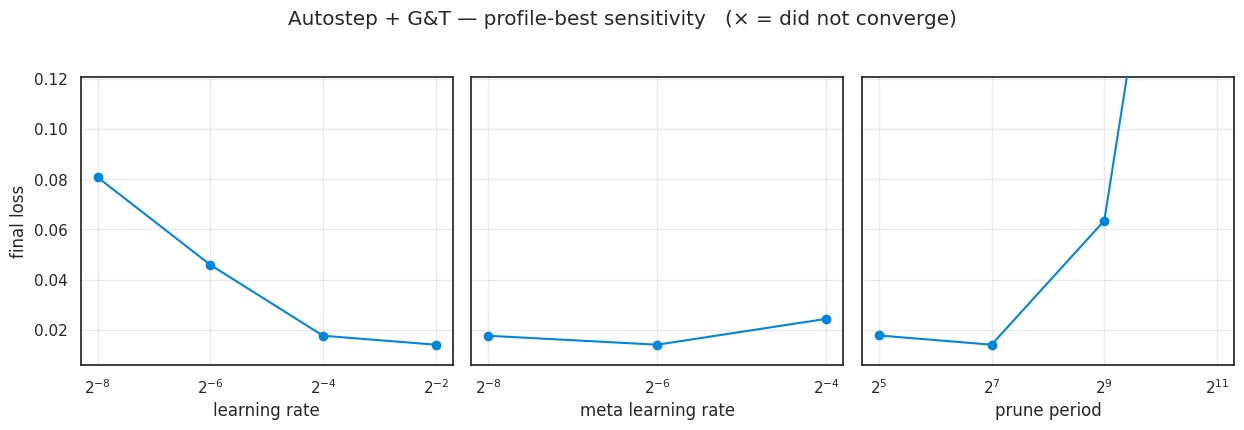

In [9]:
AUTOSTEP_GT_GRID = {
    'learning_rate': [2.0 ** e for e in range(-8, -1, 2)],       # 2^-8 .. 2^-2
    'meta_learning_rate': [2.0 ** e for e in range(-8, -3, 2)],  # 2^-6 .. 2^-2
    'prune_period': [2 ** 5, 2 ** 7, 2 ** 9, 2 ** 11],
}
run_method_sweep(METHODS['autostep_gt'], AUTOSTEP_GT_GRID, N_SWEEP_SEEDS)
cfgs, runs = load_sweep_data()
autostep_gt_summary = summarize_runs(cfgs, runs, 'autostep_gt', swept_vars(AUTOSTEP_GT_GRID), FINAL_FRACTION, BASELINE_LOSS)
plot_sensitivity(autostep_gt_summary, swept_vars(AUTOSTEP_GT_GRID), 'Autostep + G&T')
plt.show()

### Autostep + G&T — best configuration learning curve (30 seeds)

[I 2026-08-07 12:01:19,381] A new study created in RDB with name: feature_sifting_protection/autostep_gt_best


INFO:mlflow_sweeper.runner:Creating new parent MLflow run: autostep_gt_best.
INFO:mlflow_sweeper.runner:Sweep run #0.
INFO:mlflow_sweeper.runner:Created trial MLflow run: 498afc5ee5d943ad80ec46d189bf095f.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(learning_rate=0.25, meta_learning_rate=0.015625, prune_period=128.0, n_seeds=30)`


Autostep + G&T best: {'learning_rate': 0.25, 'meta_learning_rate': 0.015625, 'prune_period': 128.0}


[I 2026-08-07 12:01:23,129] Trial 0 finished with value: 0.018716625689208146 and parameters: {}. Best is trial 0 with value: 0.018716625689208146.
INFO:mlflow_sweeper.runner:Sweep autostep_gt_best completed.
INFO:phd.research_utils.scripts.mlflow_download:Tracking URI: sqlite:////home/edan/local_projects/phd_research/phd/sandbox/feature_sifting/exploration/output/mlruns.db
INFO:phd.research_utils.scripts.mlflow_download:Found experiment 'feature_sifting_protection' (id=2)
INFO:phd.research_utils.scripts.mlflow_download:Found 66 runs
INFO:phd.research_utils.scripts.mlflow_download:Discovered 4 metric names from 10 sample runs
INFO:phd.research_utils.scripts.mlflow_download:Metrics to download: ['final_loss', 'final_loss_std', 'loss', 'loss_std']
Downloading: 100%|██████████| 66/66 [00:09<00:00,  7.02it/s]
INFO:phd.research_utils.scripts.mlflow_download:Saved 66 param rows to /home/edan/local_projects/phd_research/phd/sandbox/feature_sifting/exploration/data/feature_sifting_protection_p

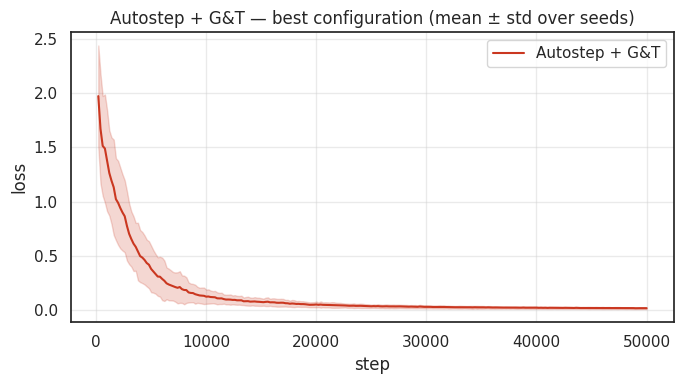

In [10]:
autostep_gt_best = best_hparams(cfgs, runs, METHODS['autostep_gt'], AUTOSTEP_GT_GRID)
print('Autostep + G&T best:', autostep_gt_best)
run_method_sweep(METHODS['autostep_gt'], autostep_gt_best, N_CURVE_SEEDS, sweep_name='autostep_gt_best')
cfgs, runs = load_sweep_data()

plt.figure(figsize=(7, 4))
plot_learning_curve(runs, 'autostep_gt_best', label='Autostep + G&T', color=get_color_palette(n=4)[1])
plt.title('Autostep + G&T — best configuration (mean ± std over seeds)')
plt.legend(); plt.tight_layout(); plt.show()

## 3. Autostep + G&T + step-size protection (median threshold)

Event-driven pruning instead of a fixed clock. Autostep's per-feature gradient trace `h` flipping sign is
the classic signal that a step-size overshot — a natural "test" event. When `h_i` flips sign this step, the
feature is pruned **only if** its weight magnitude is in the bottom half of the current weights
(`|w_i| < median |w|`), so a large, clearly-useful weight is never thrown away just for wobbling. Sweeps the
initial step-size and the meta step-size.

In [11]:
class AutostepMedianProtect(eqx.Module):
    """Autostep + G&T with median-threshold step-size protection. A feature is pruned the step its
    Autostep gradient trace `h` flips sign, but only if its weight magnitude is in the bottom half of
    the current weights (|w_i| < median |w|)."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls, hparams, key):
        n = N_LEARNER_FEATURES
        optimizer = optax_idbd(init_lr=hparams['learning_rate'],
                               meta_lr=hparams['meta_learning_rate'], autostep=True)
        w = jnp.zeros((1, n))
        return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
                   prune_mask=jnp.zeros(n, dtype=bool))

    def step(self, x, y):
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        h_prev = self.opt_state.h
        updates, opt_state = self.optimizer.update((loss_grads, x[None, :]), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)

        # Prune features whose h flipped sign this step AND whose |weight| is in the bottom half.
        flipped = (h_prev * opt_state.h < 0.0)[0]        # (n,)
        util = jnp.abs(w[0])                             # (n,)
        prune_mask = flipped & (util < jnp.median(util))
        w = jnp.where(prune_mask[None, :], 0.0, w)
        opt_state = reset_idbd_state(opt_state, prune_mask)

        return tree_replace(self, w=w, opt_state=opt_state, prune_mask=prune_mask), loss


AUTOSTEP_MEDIAN_DEFAULTS = {'learning_rate': 2.0 ** -2, 'meta_learning_rate': 2.0 ** -4}
METHODS['autostep_median'] = MethodSpec('autostep_median', 'Autostep + G&T + protection (median)',
                                        AutostepMedianProtect, AUTOSTEP_MEDIAN_DEFAULTS)

[I 2026-08-07 12:01:32,987] A new study created in RDB with name: feature_sifting_protection/autostep_median


INFO:mlflow_sweeper.runner:Creating new parent MLflow run: autostep_median.
INFO:mlflow_sweeper.runner:Sweep run #0.
INFO:mlflow_sweeper.runner:Created trial MLflow run: 156c0eca6f604b6a8ef0f594d4f687ad.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(learning_rate=0.0625, meta_learning_rate=0.015625, n_seeds=5)`
[I 2026-08-07 12:01:36,898] Trial 0 finished with value: 0.23268737773475934 and parameters: {'learning_rate': 0.0625, 'meta_learning_rate': 0.015625}. Best is trial 0 with value: 0.23268737773475934.
INFO:mlflow_sweeper.runner:Sweep run #1.
INFO:mlflow_sweeper.runner:Created trial MLflow run: 7363cfb8556a490cb5b40e64e97ff1f4.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(learning_rate=0.00390625, meta_learning_rate=0.25, n_seeds=5)`
[I 2026-08-07 12:01:40,693] Trial 1 finished with value: 0.3915413630743493 and parameters: {'learning_rate': 0.00390625, 'meta_learning_rate': 0.25}. Best is tr

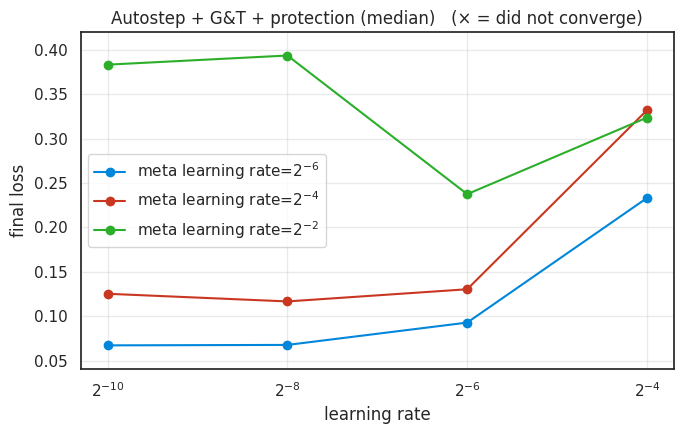

In [12]:
AUTOSTEP_MEDIAN_GRID = {
    'learning_rate': [2.0 ** e for e in range(-10, -3, 2)],       # 2^-8 .. 2^-2
    'meta_learning_rate': [2.0 ** e for e in range(-6, -1, 2)],  # 2^-6 .. 2^-2
}
run_method_sweep(METHODS['autostep_median'], AUTOSTEP_MEDIAN_GRID, N_SWEEP_SEEDS)
cfgs, runs = load_sweep_data()
autostep_median_summary = summarize_runs(cfgs, runs, 'autostep_median', swept_vars(AUTOSTEP_MEDIAN_GRID), FINAL_FRACTION, BASELINE_LOSS)
plot_sensitivity(autostep_median_summary, swept_vars(AUTOSTEP_MEDIAN_GRID), 'Autostep + G&T + protection (median)')
plt.show()

### Median-threshold protection — best configuration learning curve (30 seeds)

[I 2026-08-07 12:02:30,402] A new study created in RDB with name: feature_sifting_protection/autostep_median_best


INFO:mlflow_sweeper.runner:Creating new parent MLflow run: autostep_median_best.
INFO:mlflow_sweeper.runner:Sweep run #0.
INFO:mlflow_sweeper.runner:Created trial MLflow run: ffc3f60c344b41f3a19bb16fd82ff706.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(learning_rate=0.0009765625, meta_learning_rate=0.015625, n_seeds=30)`


Autostep + G&T + protection (median) best: {'learning_rate': 0.0009765625, 'meta_learning_rate': 0.015625}


[I 2026-08-07 12:02:34,401] Trial 0 finished with value: 0.07365491189136913 and parameters: {}. Best is trial 0 with value: 0.07365491189136913.
INFO:mlflow_sweeper.runner:Sweep autostep_median_best completed.
INFO:phd.research_utils.scripts.mlflow_download:Tracking URI: sqlite:////home/edan/local_projects/phd_research/phd/sandbox/feature_sifting/exploration/output/mlruns.db
INFO:phd.research_utils.scripts.mlflow_download:Found experiment 'feature_sifting_protection' (id=2)
INFO:phd.research_utils.scripts.mlflow_download:Found 81 runs
INFO:phd.research_utils.scripts.mlflow_download:Discovered 4 metric names from 10 sample runs
INFO:phd.research_utils.scripts.mlflow_download:Metrics to download: ['final_loss', 'final_loss_std', 'loss', 'loss_std']
Downloading: 100%|██████████| 81/81 [00:11<00:00,  7.22it/s]
INFO:phd.research_utils.scripts.mlflow_download:Saved 81 param rows to /home/edan/local_projects/phd_research/phd/sandbox/feature_sifting/exploration/data/feature_sifting_protection

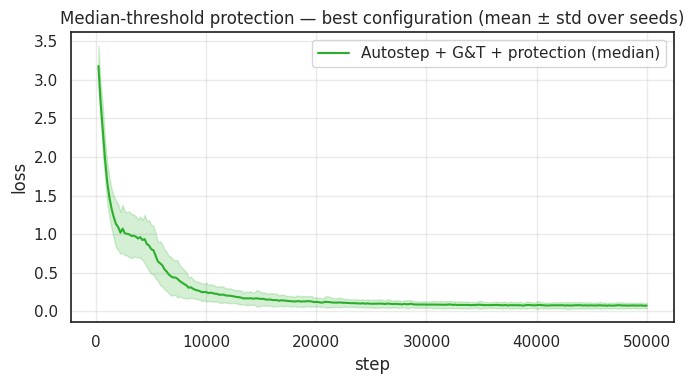

In [13]:
autostep_median_best = best_hparams(cfgs, runs, METHODS['autostep_median'], AUTOSTEP_MEDIAN_GRID)
print('Autostep + G&T + protection (median) best:', autostep_median_best)
run_method_sweep(METHODS['autostep_median'], autostep_median_best, N_CURVE_SEEDS, sweep_name='autostep_median_best')
cfgs, runs = load_sweep_data()

plt.figure(figsize=(7, 4))
plot_learning_curve(runs, 'autostep_median_best', label='Autostep + G&T + protection (median)',
                    color=get_color_palette(n=4)[2])
plt.title('Median-threshold protection — best configuration (mean ± std over seeds)')
plt.legend(); plt.tight_layout(); plt.show()

## 4. Autostep + G&T + step-size protection (sign-flip inside the jitter band)

The first method to use an explicit *noise floor*. For a dead (pure-noise) feature both the weight and the
Autostep gradient trace are stationary, with one-sigma jitter bands set entirely by the learned step-size and
the residual power (`lasso_step_size_protection_algo.ipynb`, section 1):

$$s_i = \sqrt{\frac{\alpha_i \, \mathbb{E}[\delta^2]}{2}}, \qquad |w_i| \le s_i, \qquad
  |h_i| \le \frac{s_i}{\sqrt 2}$$

so the floor needs nothing but $\alpha_i$ (which Autostep already learns) and one global estimate of
$\mathbb{E}[\delta^2]$ — the `v` trace, on the learner's own adaptation horizon. A feature is pruned when its
weight **crosses zero** while $h_i^2$ sits inside the band, i.e. $h_i^2 \le \alpha_i \mathbb{E}[\delta^2]/4$:
the weight is at zero with nothing pushing it anywhere. Detection power is uniform in step-size — a dead
feature is pruned within one or two of its own weight crossings at any $\alpha$. Sweeps the initial step-size
and the meta step-size.

In [14]:
K_V = 5.0  # the v trace averages over ~K_V of the learner's own adaptation timescales


class AutostepSignFlipProtect(eqx.Module):
    """Autostep + G&T with noise-floor sign-flip pruning. For a dead feature the weight and the
    Autostep trace `h` are stationary inside one-sigma jitter bands `s_i` and `s_i / sqrt(2)`, with
    `s_i^2 = alpha_i * E[delta^2] / 2` (the `E[x^2]` cancels), so the floor is built entirely from the
    learned step-size and a global estimate `v` of the residual power. A feature is pruned when its
    weight crosses zero while `h^2` is inside its band -- the weight is at zero while `h` is
    statistically indistinguishable from noise. Detection power is uniform in step-size: a dead
    feature is pruned within ~1-2 of its own weight crossings at any alpha.

    Note: fresh features start at exactly (w=0, h=0), inside the band by construction, so some
    useful newborns are pruned in their first few steps before h escapes it. This churn is accepted:
    culled useful features are simply regenerated, while dead features are culled in a handful of
    steps with no unprunable states. (Method 6 removes it with an arming flag.)"""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    v: jax.Array         # scalar EMA of delta^2 (global residual power)
    prune_mask: jax.Array

    @classmethod
    def init(cls, hparams, key):
        n = N_LEARNER_FEATURES
        optimizer = optax_idbd(init_lr=hparams['learning_rate'],
                               meta_lr=hparams['meta_learning_rate'], autostep=True)
        w = jnp.zeros((1, n))
        return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
                   v=jnp.asarray(0.0), prune_mask=jnp.zeros(n, dtype=bool))

    def step(self, x, y):
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        w_prev = self.w
        updates, opt_state = self.optimizer.update((loss_grads, x[None, :]), self.opt_state, self.w)
        w_new = optax.apply_updates(self.w, updates)
        w_flip = (w_prev * w_new < 0.0)[0]

        step_size = jnp.exp(opt_state.beta)[0]
        effective_lr = jnp.sum(step_size * x ** 2)
        v = self.v + (effective_lr / K_V) * (loss - self.v)

        # Prune when the weight crosses zero while h is inside its one-sigma jitter band. That band
        # is s / sqrt(2) with s^2 = alpha * E[delta^2] / 2, hence alpha * E[delta^2] / 4 on h^2.
        band_h2 = step_size * v / 4.0                        # (n,)
        prune_mask = w_flip & (opt_state.h[0] ** 2 < band_h2)

        w_new = jnp.where(prune_mask[None, :], 0.0, w_new)
        opt_state = reset_idbd_state(opt_state, prune_mask)

        return tree_replace(self, w=w_new, opt_state=opt_state, v=v, prune_mask=prune_mask), loss


AUTOSTEP_SIGNFLIP_DEFAULTS = {'learning_rate': 2.0 ** -2, 'meta_learning_rate': 2.0 ** -4}
METHODS['autostep_signflip'] = MethodSpec('autostep_signflip', 'Autostep + G&T + protection (sign-flip)',
                                          AutostepSignFlipProtect, AUTOSTEP_SIGNFLIP_DEFAULTS)

[I 2026-08-07 12:02:46,118] A new study created in RDB with name: feature_sifting_protection/autostep_signflip


INFO:mlflow_sweeper.runner:Creating new parent MLflow run: autostep_signflip.
INFO:mlflow_sweeper.runner:Sweep run #0.
INFO:mlflow_sweeper.runner:Created trial MLflow run: 7bd52c151e6f4691a4088d462fc2991d.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(learning_rate=0.25, meta_learning_rate=0.015625, n_seeds=5)`
[I 2026-08-07 12:02:49,727] Trial 0 finished with value: 0.03696597120782874 and parameters: {'learning_rate': 0.25, 'meta_learning_rate': 0.015625}. Best is trial 0 with value: 0.03696597120782874.
INFO:mlflow_sweeper.runner:Sweep run #1.
INFO:mlflow_sweeper.runner:Created trial MLflow run: 85f2d866e86049689e7fba9ffd91b76e.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(learning_rate=0.015625, meta_learning_rate=0.25, n_seeds=5)`
[I 2026-08-07 12:02:53,371] Trial 1 finished with value: 0.20853811642417597 and parameters: {'learning_rate': 0.015625, 'meta_learning_rate': 0.25}. Best is trial 0

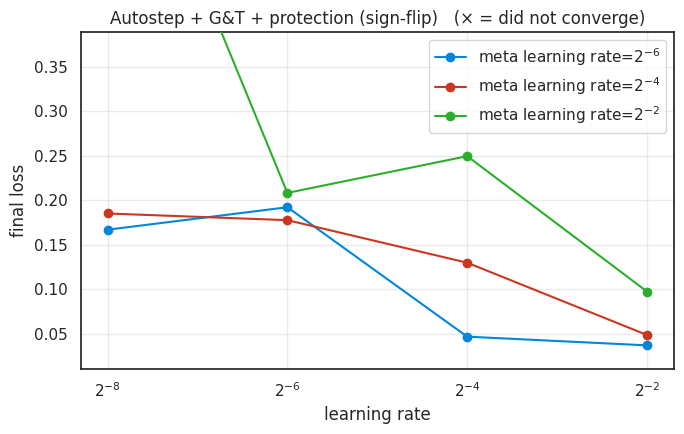

In [15]:
AUTOSTEP_SIGNFLIP_GRID = {
    'learning_rate': [2.0 ** e for e in range(-8, -1, 2)],       # 2^-8 .. 2^-2
    'meta_learning_rate': [2.0 ** e for e in range(-6, -1, 2)],  # 2^-6 .. 2^-2
}
run_method_sweep(METHODS['autostep_signflip'], AUTOSTEP_SIGNFLIP_GRID, N_SWEEP_SEEDS)
cfgs, runs = load_sweep_data()
autostep_signflip_summary = summarize_runs(cfgs, runs, 'autostep_signflip', swept_vars(AUTOSTEP_SIGNFLIP_GRID), FINAL_FRACTION, BASELINE_LOSS)
plot_sensitivity(autostep_signflip_summary, swept_vars(AUTOSTEP_SIGNFLIP_GRID), 'Autostep + G&T + protection (sign-flip)')
plt.show()

### Sign-flip protection — best configuration learning curve (30 seeds)

[I 2026-08-07 12:03:43,225] A new study created in RDB with name: feature_sifting_protection/autostep_signflip_best


INFO:mlflow_sweeper.runner:Creating new parent MLflow run: autostep_signflip_best.
INFO:mlflow_sweeper.runner:Sweep run #0.
INFO:mlflow_sweeper.runner:Created trial MLflow run: e5138b7f55514d52a5efb438bbee05ba.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(learning_rate=0.25, meta_learning_rate=0.015625, n_seeds=30)`


Autostep + G&T + protection (sign-flip) best: {'learning_rate': 0.25, 'meta_learning_rate': 0.015625}


[I 2026-08-07 12:03:46,936] Trial 0 finished with value: 0.03887866612785372 and parameters: {}. Best is trial 0 with value: 0.03887866612785372.
INFO:mlflow_sweeper.runner:Sweep autostep_signflip_best completed.
INFO:phd.research_utils.scripts.mlflow_download:Tracking URI: sqlite:////home/edan/local_projects/phd_research/phd/sandbox/feature_sifting/exploration/output/mlruns.db
INFO:phd.research_utils.scripts.mlflow_download:Found experiment 'feature_sifting_protection' (id=2)
INFO:phd.research_utils.scripts.mlflow_download:Found 96 runs
INFO:phd.research_utils.scripts.mlflow_download:Discovered 4 metric names from 10 sample runs
INFO:phd.research_utils.scripts.mlflow_download:Metrics to download: ['final_loss', 'final_loss_std', 'loss', 'loss_std']
Downloading: 100%|██████████| 96/96 [00:13<00:00,  7.05it/s]
INFO:phd.research_utils.scripts.mlflow_download:Saved 96 param rows to /home/edan/local_projects/phd_research/phd/sandbox/feature_sifting/exploration/data/feature_sifting_protecti

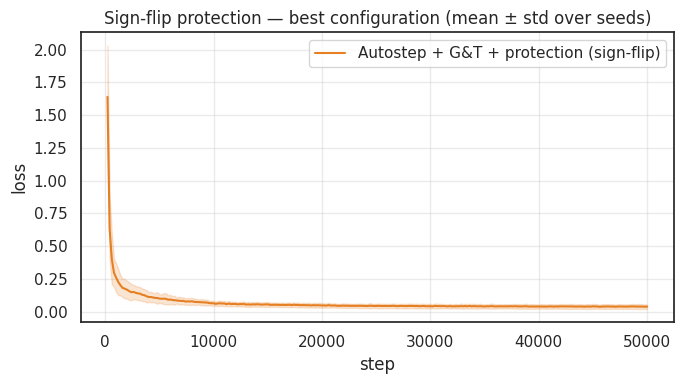

In [16]:
autostep_signflip_best = best_hparams(cfgs, runs, METHODS['autostep_signflip'], AUTOSTEP_SIGNFLIP_GRID)
print('Autostep + G&T + protection (sign-flip) best:', autostep_signflip_best)
run_method_sweep(METHODS['autostep_signflip'], autostep_signflip_best, N_CURVE_SEEDS, sweep_name='autostep_signflip_best')
cfgs, runs = load_sweep_data()

plt.figure(figsize=(7, 4))
plot_learning_curve(runs, 'autostep_signflip_best', label='Autostep + G&T + protection (sign-flip)',
                    color=get_color_palette(n=5)[4])
plt.title('Sign-flip protection — best configuration (mean ± std over seeds)')
plt.legend(); plt.tight_layout(); plt.show()

## 5. Autostep + L1 + G&T (prune on a weight zero-crossing)

L1 instead of a threshold. The subgradient $\lambda\,\mathrm{sign}(w)$ joins the loss gradient (with
$\lambda = 0.001$), so Autostep's step-size adaptation sees it too — the same convention as
`lasso_step_size_protection_algo.ipynb`. L1 pulls every weight toward zero and only a real gradient holds one
away from it: a dead feature therefore sits at zero and crosses it constantly, while a useful feature settles
at its own $w^\ast$ and stops crossing. The entire test is `w` changing sign — no band, no threshold, no
clock, and nothing to estimate online.

The L1 term also moves the weight jitter band down to $|w_i| \le s_i - \lambda / \mathbb{E}[x_i^2]$, which is
what makes the crossing test sharp: for a dead feature the band is (nearly) zero, so "at zero" and "dead"
become the same statement. Sweeps the initial step-size and the meta step-size at fixed $\lambda$.

In [17]:
L1_COEFF = 0.001   # lambda in the loss gradient, shared by methods 5 and 6


class AutostepL1ZeroCross(eqx.Module):
    """LMS + L1 + Autostep, pruning on weight zero-crossings. The L1 subgradient
    `lambda * sign(w)` is added to the loss gradient, so it drives the weight update *and* Autostep's
    step-size adaptation and gradient trace. L1 pulls every weight toward zero and only a genuine
    gradient holds one away from it, so a dead feature crosses zero constantly while a useful one
    settles at its own w* and stops crossing: the whole test is `w` changing sign."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    l1_coeff: float = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls, hparams, key):
        n = N_LEARNER_FEATURES
        optimizer = optax_idbd(init_lr=hparams['learning_rate'],
                               meta_lr=hparams['meta_learning_rate'], autostep=True)
        w = jnp.zeros((1, n))
        return cls(optimizer=optimizer, l1_coeff=float(hparams['l1_coefficient']),
                   w=w, opt_state=optimizer.init(w), prune_mask=jnp.zeros(n, dtype=bool))

    def step(self, x, y):
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        loss_grads = loss_grads + self.l1_coeff * jnp.sign(self.w)   # L1 inside the gradient
        updates, opt_state = self.optimizer.update((loss_grads, x[None, :]), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)

        # Prune every feature whose weight changed sign this step (a fresh feature sits at exactly
        # w = 0, so the product is zero and it is never pruned on arrival).
        prune_mask = (self.w * w < 0.0)[0]
        w = jnp.where(prune_mask[None, :], 0.0, w)
        opt_state = reset_idbd_state(opt_state, prune_mask)

        return tree_replace(self, w=w, opt_state=opt_state, prune_mask=prune_mask), loss


AUTOSTEP_L1_DEFAULTS = {'learning_rate': 2.0 ** -2, 'meta_learning_rate': 2.0 ** -4,
                        'l1_coefficient': L1_COEFF}
METHODS['autostep_l1'] = MethodSpec('autostep_l1', 'Autostep + L1 + G&T (zero-crossing)',
                                    AutostepL1ZeroCross, AUTOSTEP_L1_DEFAULTS)

[I 2026-08-07 12:04:01,087] A new study created in RDB with name: feature_sifting_protection/autostep_l1
INFO:mlflow_sweeper.runner:Creating new parent MLflow run: autostep_l1.
INFO:mlflow_sweeper.runner:Sweep run #0.
INFO:mlflow_sweeper.runner:Created trial MLflow run: 8c8e4a55e830422aa9011b76fa2a5917.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(learning_rate=0.25, meta_learning_rate=0.015625, n_seeds=5)`
[I 2026-08-07 12:04:04,639] Trial 0 finished with value: 0.0548076678445949 and parameters: {'learning_rate': 0.25, 'meta_learning_rate': 0.015625}. Best is trial 0 with value: 0.0548076678445949.
INFO:mlflow_sweeper.runner:Sweep run #1.
INFO:mlflow_sweeper.runner:Created trial MLflow run: d8f272c97c374e0382da1c437d52ed8f.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(learning_rate=0.015625, meta_learning_rate=0.25, n_seeds=5)`
[I 2026-08-07 12:04:08,150] Trial 1 finished with value: 0.310816388

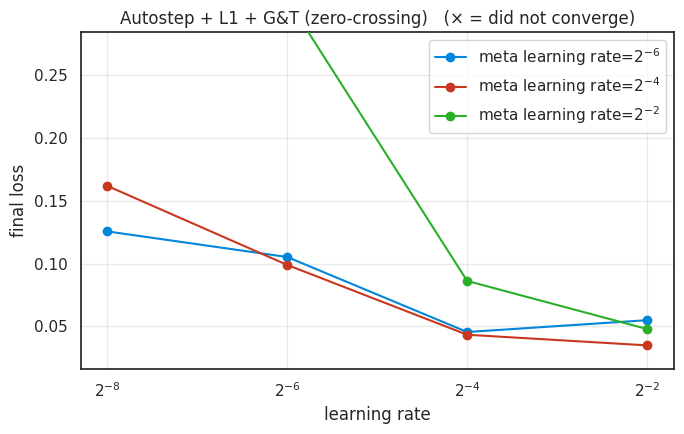

In [18]:
AUTOSTEP_L1_GRID = {
    'learning_rate': [2.0 ** e for e in range(-8, -1, 2)],       # 2^-8 .. 2^-2  (initial step-size)
    'meta_learning_rate': [2.0 ** e for e in range(-6, -1, 2)],  # 2^-6 .. 2^-2
}
run_method_sweep(METHODS['autostep_l1'], AUTOSTEP_L1_GRID, N_SWEEP_SEEDS)
cfgs, runs = load_sweep_data()
autostep_l1_summary = summarize_runs(cfgs, runs, 'autostep_l1', swept_vars(AUTOSTEP_L1_GRID), FINAL_FRACTION, BASELINE_LOSS)
plot_sensitivity(autostep_l1_summary, swept_vars(AUTOSTEP_L1_GRID), 'Autostep + L1 + G&T (zero-crossing)')
plt.show()

### Autostep + L1 (zero-crossing) — best configuration learning curve (30 seeds)

[I 2026-08-07 12:04:58,669] A new study created in RDB with name: feature_sifting_protection/autostep_l1_best
INFO:mlflow_sweeper.runner:Creating new parent MLflow run: autostep_l1_best.
INFO:mlflow_sweeper.runner:Sweep run #0.
INFO:mlflow_sweeper.runner:Created trial MLflow run: 69244d03f9874c34bf6004fb6e9ef8e5.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(learning_rate=0.25, meta_learning_rate=0.0625, n_seeds=30)`


Autostep + L1 + G&T (zero-crossing) best: {'learning_rate': 0.25, 'meta_learning_rate': 0.0625}


[I 2026-08-07 12:05:02,347] Trial 0 finished with value: 0.04413684145935185 and parameters: {}. Best is trial 0 with value: 0.04413684145935185.
INFO:mlflow_sweeper.runner:Sweep autostep_l1_best completed.
INFO:phd.research_utils.scripts.mlflow_download:Tracking URI: sqlite:////home/edan/local_projects/phd_research/phd/sandbox/feature_sifting/exploration/output/mlruns.db
INFO:phd.research_utils.scripts.mlflow_download:Found experiment 'feature_sifting_protection' (id=2)
INFO:phd.research_utils.scripts.mlflow_download:Found 111 runs
INFO:phd.research_utils.scripts.mlflow_download:Discovered 4 metric names from 10 sample runs
INFO:phd.research_utils.scripts.mlflow_download:Metrics to download: ['final_loss', 'final_loss_std', 'loss', 'loss_std']
Downloading: 100%|██████████| 111/111 [00:15<00:00,  7.32it/s]
INFO:phd.research_utils.scripts.mlflow_download:Saved 111 param rows to /home/edan/local_projects/phd_research/phd/sandbox/feature_sifting/exploration/data/feature_sifting_protection

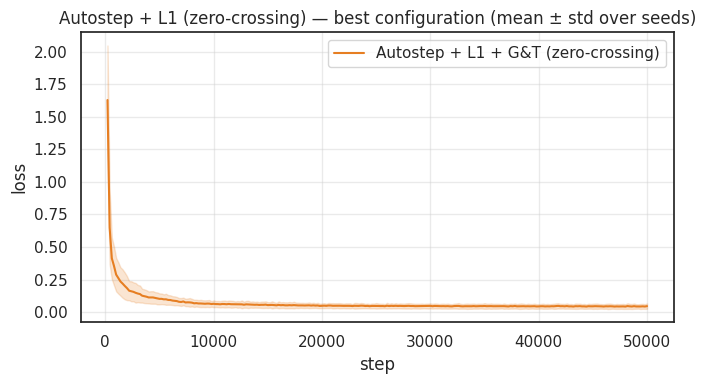

In [19]:
autostep_l1_best = best_hparams(cfgs, runs, METHODS['autostep_l1'], AUTOSTEP_L1_GRID)
print('Autostep + L1 + G&T (zero-crossing) best:', autostep_l1_best)
run_method_sweep(METHODS['autostep_l1'], autostep_l1_best, N_CURVE_SEEDS, sweep_name='autostep_l1_best')
cfgs, runs = load_sweep_data()

plt.figure(figsize=(7, 4))
plot_learning_curve(runs, 'autostep_l1_best', label='Autostep + L1 + G&T (zero-crossing)',
                    color=get_color_palette(n=6)[4])
plt.title('Autostep + L1 (zero-crossing) — best configuration (mean ± std over seeds)')
plt.legend(); plt.tight_layout(); plt.show()

## 6. Autostep + L1 + G&T (armed jitter band)

Method 5 with the jitter band of method 4 layered on, in two roles:

- **Arming.** A newborn feature sits at $w_i = h_i = 0$ — a quiet gradient by construction, which is exactly
  what the second kill below looks for. That kill therefore applies only once $|h_i|$ has left its band
  $s_i/\sqrt2$ at least once: arming stands in for an age counter, with no clock and no extra
  hyperparameter. A kill de-arms the slot again.
- **A second kill: the gradient going quiet.** Once armed, a feature is also pruned when $|h_i|$ crosses back
  **into** its band while its utility $|w_i|$ is in the bottom half of the current weights. The weight need
  not be at zero: nothing is pushing the feature anywhere, and it is not one of the weights currently
  carrying the prediction. This catches a dead feature that L1 has parked slightly off zero, which the
  crossing test of method 5 would have to wait for.

Method 5's zero-crossing kill still fires unconditionally, so this is method 5 plus the quiet-gradient kill.
The band needs $\mathbb{E}[\delta^2]$, which the `v` trace estimates on the learner's own adaptation horizon (gain = effective step-size $/ K_V$, with the
accumulated gain dividing it back out so it reads unbiased from step 1). `v` is **not** reset by a kill: it
estimates the parent learner's residual power, not anything about the feature that was thrown away. Sweeps
the initial step-size and the meta step-size at fixed $\lambda$.

In [20]:
class AutostepL1ArmedProtect(eqx.Module):
    """Method 5 plus jitter-band arming and a quiet-gradient kill.

    A dead feature's Autostep gradient trace is stationary inside the one-sigma band
    `s_i / sqrt(2)`, with `s_i^2 = alpha_i * E[delta^2] / 2`, so `h^2 <= alpha_i * E[delta^2] / 4`
    means "this gradient is indistinguishable from noise". `E[delta^2]` is estimated by a scalar `v`
    trace on the learner's own adaptation horizon (`trace_weight` divides the accumulated gain back
    out so `v` is unbiased from the first step). Two uses of the band:

    * *Arming* -- the quiet-gradient kill below applies only once `|h_i|` has left the band at least
      once. A newborn sits at `w_i = h_i = 0`, a quiet gradient by construction, so arming holds that
      kill off it until it has shown a real gradient -- with no age counter. A kill de-arms the slot.
    * *Quiet-gradient kill* -- once armed, prune when `|h_i|` crosses back **into** the band and the
      feature's utility `|w_i|` is in the bottom half of the current weights.

    Method 5's zero-crossing kill still fires unconditionally, so this is method 5 plus the kill
    above. `v` is not reset on a kill: it belongs to the parent learner's residual, not to the
    feature being replaced."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    l1_coeff: float = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    v: jax.Array             # scalar EMA of delta^2 (global residual power)
    trace_weight: jax.Array  # accumulated trace gain, so v reads unbiased from step 1
    armed: jax.Array         # (n,) has |h| left its band since this slot was last filled?
    quiet: jax.Array         # (n,) was |h| inside its band last step? (for the crossing test)
    prune_mask: jax.Array

    @classmethod
    def init(cls, hparams, key):
        n = N_LEARNER_FEATURES
        optimizer = optax_idbd(init_lr=hparams['learning_rate'],
                               meta_lr=hparams['meta_learning_rate'], autostep=True)
        w = jnp.zeros((1, n))
        return cls(optimizer=optimizer, l1_coeff=float(hparams['l1_coefficient']),
                   w=w, opt_state=optimizer.init(w), v=jnp.asarray(0.0),
                   trace_weight=jnp.asarray(0.0), armed=jnp.zeros(n, dtype=bool),
                   quiet=jnp.ones(n, dtype=bool),        # a newborn h = 0 is inside its band
                   prune_mask=jnp.zeros(n, dtype=bool))

    def step(self, x, y):
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        loss_grads = loss_grads + self.l1_coeff * jnp.sign(self.w)   # L1 inside the gradient
        updates, opt_state = self.optimizer.update((loss_grads, x[None, :]), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)

        # E[delta^2] on the learner's own timescale; trace_weight makes it unbiased from step 1.
        step_size = jnp.exp(opt_state.beta)[0]               # (n,) per-feature step-size
        gain = jnp.sum(step_size * x ** 2) / K_V             # effective step-size / K_V
        v = self.v + gain * (loss - self.v)
        trace_weight = self.trace_weight + gain * (1.0 - self.trace_weight)
        delta2 = v / jnp.maximum(trace_weight, 1e-12)

        # One-sigma jitter band for h: s / sqrt(2), i.e. alpha * E[delta^2] / 4 on h^2.
        band_h2 = step_size * delta2 / 4.0                   # (n,)
        quiet = opt_state.h[0] ** 2 <= band_h2               # h indistinguishable from noise
        armed = self.armed | ~quiet                          # ... it has to have escaped once

        util = jnp.abs(w[0])
        w_cross = (self.w * w < 0.0)[0]                      # weight changed sign (method 5)
        h_cross_in = quiet & ~self.quiet                     # h came back inside its band
        prune_mask = w_cross | (armed & h_cross_in & (util < jnp.median(util)))

        w = jnp.where(prune_mask[None, :], 0.0, w)
        opt_state = reset_idbd_state(opt_state, prune_mask)  # v (the delta^2 trace) is not reset
        armed = armed & ~prune_mask                          # a fresh feature starts un-armed ...
        quiet = quiet | prune_mask                           # ... at h = 0, inside its band

        return tree_replace(self, w=w, opt_state=opt_state, v=v, trace_weight=trace_weight,
                            armed=armed, quiet=quiet, prune_mask=prune_mask), loss


AUTOSTEP_L1_ARMED_DEFAULTS = {'learning_rate': 2.0 ** -2, 'meta_learning_rate': 2.0 ** -4,
                              'l1_coefficient': L1_COEFF}
METHODS['autostep_l1_armed'] = MethodSpec('autostep_l1_armed', 'Autostep + L1 + G&T (armed band)',
                                          AutostepL1ArmedProtect, AUTOSTEP_L1_ARMED_DEFAULTS)

[I 2026-08-07 12:05:18,075] A new study created in RDB with name: feature_sifting_protection/autostep_l1_armed
INFO:mlflow_sweeper.runner:Creating new parent MLflow run: autostep_l1_armed.
INFO:mlflow_sweeper.runner:Sweep run #0.
INFO:mlflow_sweeper.runner:Created trial MLflow run: a02410c2a59646a0a211c95c526d8fc7.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(learning_rate=0.25, meta_learning_rate=0.015625, n_seeds=5)`
[I 2026-08-07 12:05:22,086] Trial 0 finished with value: 0.534701467516351 and parameters: {'learning_rate': 0.25, 'meta_learning_rate': 0.015625}. Best is trial 0 with value: 0.534701467516351.
INFO:mlflow_sweeper.runner:Sweep run #1.
INFO:mlflow_sweeper.runner:Created trial MLflow run: 4bd2d00f4f12427a8b98c8df01c8e69c.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(learning_rate=0.015625, meta_learning_rate=0.25, n_seeds=5)`
[I 2026-08-07 12:05:26,087] Trial 1 finished with value: 0

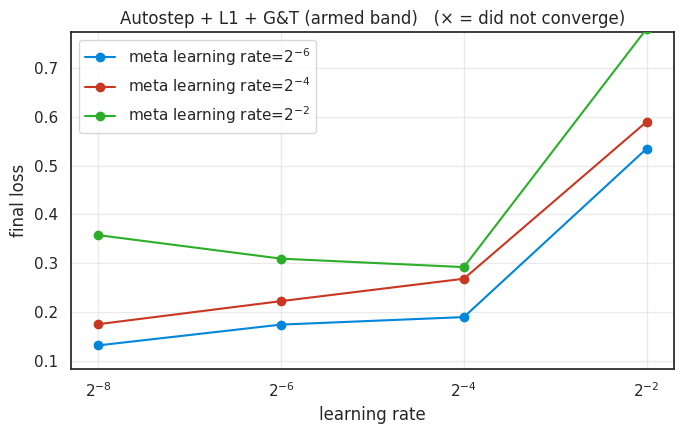

In [21]:
AUTOSTEP_L1_ARMED_GRID = {
    'learning_rate': [2.0 ** e for e in range(-8, -1, 2)],       # 2^-8 .. 2^-2  (initial step-size)
    'meta_learning_rate': [2.0 ** e for e in range(-6, -1, 2)],  # 2^-6 .. 2^-2
}
run_method_sweep(METHODS['autostep_l1_armed'], AUTOSTEP_L1_ARMED_GRID, N_SWEEP_SEEDS)
cfgs, runs = load_sweep_data()
autostep_l1_armed_summary = summarize_runs(cfgs, runs, 'autostep_l1_armed', swept_vars(AUTOSTEP_L1_ARMED_GRID),
                                           FINAL_FRACTION, BASELINE_LOSS)
plot_sensitivity(autostep_l1_armed_summary, swept_vars(AUTOSTEP_L1_ARMED_GRID),
                 'Autostep + L1 + G&T (armed band)')
plt.show()

### Autostep + L1 (armed band) — best configuration learning curve (30 seeds)

[I 2026-08-07 12:06:23,903] A new study created in RDB with name: feature_sifting_protection/autostep_l1_armed_best
INFO:mlflow_sweeper.runner:Creating new parent MLflow run: autostep_l1_armed_best.
INFO:mlflow_sweeper.runner:Sweep run #0.
INFO:mlflow_sweeper.runner:Created trial MLflow run: b1772d0512704a85836d442279d92684.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(learning_rate=0.00390625, meta_learning_rate=0.015625, n_seeds=30)`


Autostep + L1 + G&T (armed band) best: {'learning_rate': 0.00390625, 'meta_learning_rate': 0.015625}


[I 2026-08-07 12:06:28,395] Trial 0 finished with value: 0.098193870225834 and parameters: {}. Best is trial 0 with value: 0.098193870225834.
INFO:mlflow_sweeper.runner:Sweep autostep_l1_armed_best completed.
INFO:phd.research_utils.scripts.mlflow_download:Tracking URI: sqlite:////home/edan/local_projects/phd_research/phd/sandbox/feature_sifting/exploration/output/mlruns.db
INFO:phd.research_utils.scripts.mlflow_download:Found experiment 'feature_sifting_protection' (id=2)
INFO:phd.research_utils.scripts.mlflow_download:Found 126 runs
INFO:phd.research_utils.scripts.mlflow_download:Discovered 4 metric names from 10 sample runs
INFO:phd.research_utils.scripts.mlflow_download:Metrics to download: ['final_loss', 'final_loss_std', 'loss', 'loss_std']
Downloading: 100%|██████████| 126/126 [00:17<00:00,  7.38it/s]
INFO:phd.research_utils.scripts.mlflow_download:Saved 126 param rows to /home/edan/local_projects/phd_research/phd/sandbox/feature_sifting/exploration/data/feature_sifting_protecti

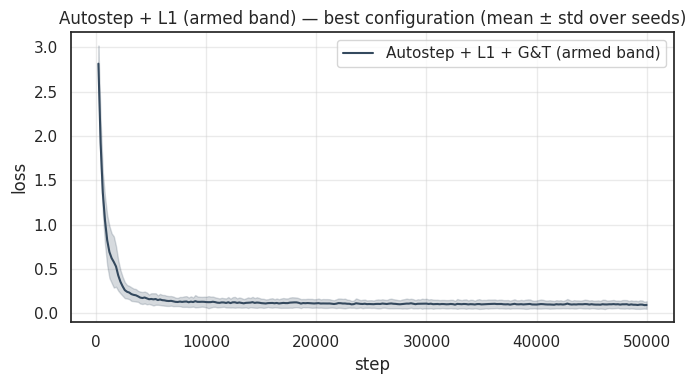

In [22]:
autostep_l1_armed_best = best_hparams(cfgs, runs, METHODS['autostep_l1_armed'], AUTOSTEP_L1_ARMED_GRID)
print('Autostep + L1 + G&T (armed band) best:', autostep_l1_armed_best)
run_method_sweep(METHODS['autostep_l1_armed'], autostep_l1_armed_best, N_CURVE_SEEDS,
                 sweep_name='autostep_l1_armed_best')
cfgs, runs = load_sweep_data()

plt.figure(figsize=(7, 4))
plot_learning_curve(runs, 'autostep_l1_armed_best', label='Autostep + L1 + G&T (armed band)',
                    color=get_color_palette(n=6)[5])
plt.title('Autostep + L1 (armed band) — best configuration (mean ± std over seeds)')
plt.legend(); plt.tight_layout(); plt.show()

## All methods — best configurations

The best configuration of each method (already run above with 30 seeds) plotted together. Data is loaded from
the cache, so this cell does not re-run any experiment.

Reusing cached CSVs (126 runs, no new data to download).


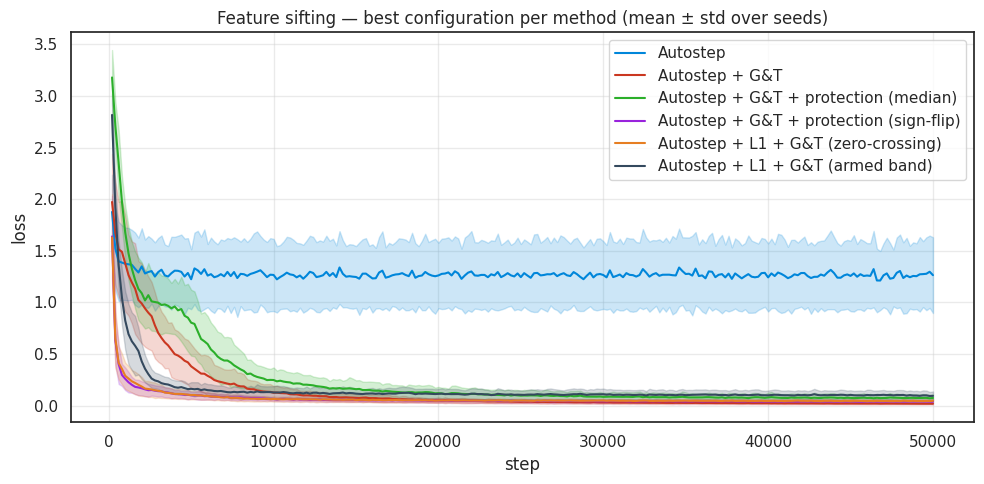

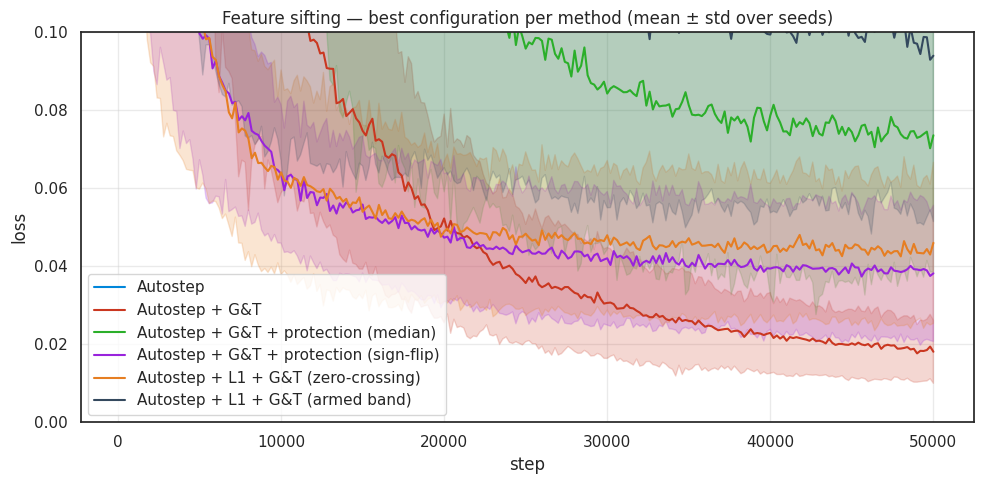

In [23]:
cfgs, runs = load_sweep_data()

best_sweeps = [(m.label, key + '_best') for key, m in METHODS.items()]
colors = get_color_palette(n=len(best_sweeps))

plt.figure(figsize=(10, 5))
ax = plt.gca()
for (label, sweep_name), color in zip(best_sweeps, colors):
    if sweep_name in runs:
        plot_learning_curve(runs, sweep_name, label=label, color=color, ax=ax)
ax.set_title('Feature sifting — best configuration per method (mean ± std over seeds)')
ax.legend()
plt.tight_layout(); plt.show()


plt.figure(figsize=(10, 5))
ax = plt.gca()
for (label, sweep_name), color in zip(best_sweeps, colors):
    if sweep_name in runs:
        plot_learning_curve(runs, sweep_name, label=label, color=color, ax=ax)
ax.set_title('Feature sifting — best configuration per method (mean ± std over seeds)')
ax.legend()
plt.ylim(0.0, 0.1)
plt.tight_layout(); plt.show()

## Loss floor and pruning rate

Two per-method diagnostics that the sweeps do **not** log (only `loss` is logged). We replay each method's
*best* configuration in-memory over the same 30 seeds and record, at every step:

* the **loss floor** — for each of the 10 unique target features, the lowest noise coefficient among the
  candidate slots currently pointing at it (`1.0` for an uncovered target), summed. It measures the quality
  of the feature set a method has assembled: a good sifter keeps low-noise candidates and drives the floor
  down, while plain Autostep (no pruning) stays at the fixed floor of its initial random features. (This is a
  feature-quality floor in units of summed noise coefficient, not a squared-error lower bound, so it is shown
  on its own axis rather than under the loss curves.)
* the **pruning rate** — the number of candidate slots regenerated per step (log scale; a method that never
  prunes is flagged in the legend).

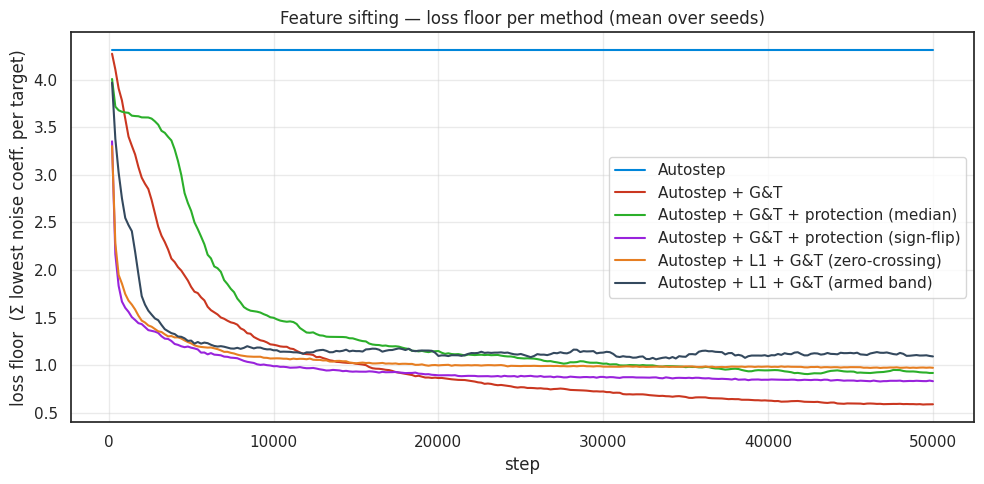

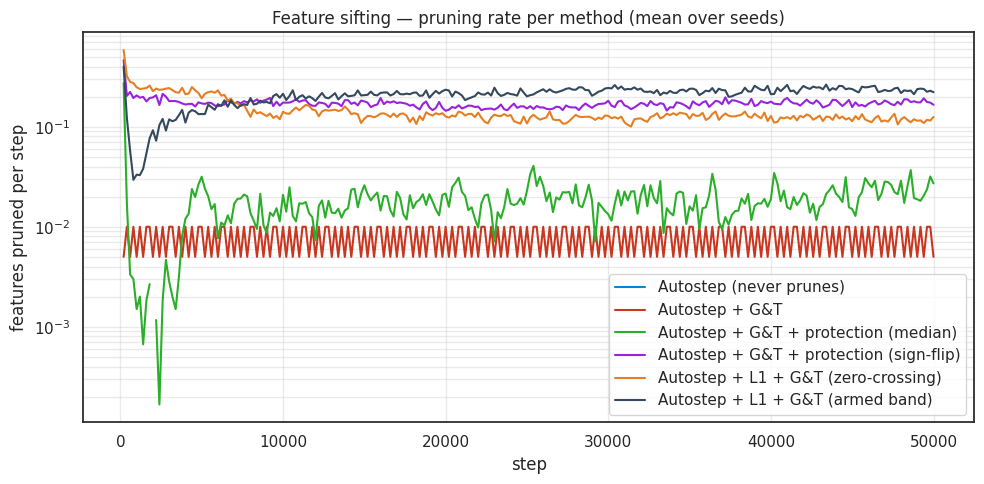

In [24]:
# Replay each method's best config in-memory, tracking the loss floor and pruning rate (neither is
# logged during the sweeps). Same hyperparameters / seeds / steps as the logged best-config curves,
# so these diagnostics correspond exactly to the loss curves plotted above.

def best_config_hparams(spec):
    """Best hyperparameters of `<name>_best`, read back from the cached sweep params (swept values
    overriding the method's non-swept defaults)."""
    if spec.name + '_best' not in cfgs:
        return dict(spec.defaults)
    row = cfgs[spec.name + '_best'].iloc[0]
    swept = {}
    for k in spec.defaults:
        if k in row.index:
            try:
                v = float(row[k])
            except (TypeError, ValueError):
                continue
            if np.isfinite(v):
                swept[k] = v
    return {**spec.defaults, **swept}


def run_with_diagnostics(method_cls, hparams, n_seeds):
    """Like `run_all_seeds`, but each step also emits the loss floor and the prune count."""
    def run_one_seed(seed_key):
        task_key, init_key = jax.random.split(seed_key)
        task = FeatureSiftingTask(N_TARGET_FEATURES, N_LEARNER_FEATURES, TARGET_NOISE_STD, key=task_key)
        state = method_cls.init(hparams, init_key)

        def scan_step(carry, _):
            task, state = carry
            task, (x, y) = task.step(state.prune_mask)
            state, _ = state.step(x, jnp.squeeze(y))
            return (task, state), (noise_floor(task), jnp.sum(state.prune_mask))

        _, out = jax.lax.scan(scan_step, (task, state), length=NUM_STEPS)
        return out   # (floor, n_pruned), each (NUM_STEPS,)

    seed_keys = jax.random.split(jax.random.PRNGKey(BASE_SEED), n_seeds)
    return jax.jit(jax.vmap(run_one_seed))(seed_keys)


def bin_over_seeds(arr, n_points=N_LOG_POINTS):
    """Bin (n_seeds, n_steps) into (n_points,) window-means, then mean over seeds — matching the
    binning `log_run` applies to the logged loss curve, so the x-axes line up."""
    arr = np.asarray(arr)
    n_seeds, n_steps = arr.shape
    w = n_steps // n_points
    binned = arr[:, :w * n_points].reshape(n_seeds, n_points, w).mean(axis=2)
    return np.arange(1, n_points + 1) * w, binned.mean(axis=0)


diagnostics = {}
for key, spec in METHODS.items():
    floor, n_pruned = run_with_diagnostics(spec.cls, best_config_hparams(spec), N_CURVE_SEEDS)
    steps, floor_curve = bin_over_seeds(floor)
    _, prune_curve = bin_over_seeds(n_pruned)
    diagnostics[key] = {'steps': steps, 'floor': floor_curve, 'prune_rate': prune_curve}

colors = get_color_palette(n=len(METHODS))   # same order/palette as the loss comparison above

# --- Loss floor per method ---
plt.figure(figsize=(10, 5))
ax = plt.gca()
for (key, spec), color in zip(METHODS.items(), colors):
    d = diagnostics[key]
    ax.plot(d['steps'], d['floor'], color=color, label=spec.label)
ax.set_xlabel('step'); ax.set_ylabel('loss floor  (Σ lowest noise coeff. per target)')
ax.set_title('Feature sifting — loss floor per method (mean over seeds)')
ax.grid(True, alpha=0.4); ax.legend()
plt.tight_layout(); plt.show()

# --- Pruning rate per method (log scale; never-pruning methods flagged in the legend) ---
plt.figure(figsize=(10, 5))
ax = plt.gca()
for (key, spec), color in zip(METHODS.items(), colors):
    d = diagnostics[key]
    if np.any(d['prune_rate'] > 0):
        ax.plot(d['steps'], np.where(d['prune_rate'] > 0, d['prune_rate'], np.nan),
                color=color, label=spec.label)
    else:
        ax.plot([], [], color=color, label=f'{spec.label} (never prunes)')
ax.set_yscale('log')
ax.set_xlabel('step'); ax.set_ylabel('features pruned per step')
ax.set_title('Feature sifting — pruning rate per method (mean over seeds)')
ax.grid(True, alpha=0.4, which='both'); ax.legend()
plt.tight_layout(); plt.show()